## TDE1 - Análise de Revisões de Compras

**Dataset:** `Flipkart Laptop Reviews` — [Kaggle](https://www.kaggle.com/datasets/gitadityamaddali/flipkart-laptop-reviews)

**Discente:** *Maria Taliciane Pereira da Silva*

**Professor:** *Alexandro Oliveira Alexandrino*

**Disciplina:** *Inteligência Artificial*

**Data:** *30/08/2026*

In [197]:
import os
import re
import glob
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats
from collections import Counter
from wordcloud import WordCloud # Importar explicitamente WordCloud aqui

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 80)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Bibliotecas importadas e ambiente configurado com sucesso.")

Bibliotecas importadas e ambiente configurado com sucesso.


In [198]:
import kagglehub

path = kagglehub.dataset_download("gitadityamaddali/flipkart-laptop-reviews")

arquivos_csv = glob.glob(os.path.join(path, "*.csv"))
assert arquivos_csv, f"Nenhum arquivo CSV encontrado em: {path}"
df = pd.read_csv(arquivos_csv[0])

print("Path to dataset files:", path)
print("DataFrame carregado:", os.path.basename(arquivos_csv[0]), df.shape)

Using Colab cache for faster access to the 'flipkart-laptop-reviews' dataset.
Path to dataset files: /kaggle/input/flipkart-laptop-reviews
DataFrame carregado: laptops_dataset_final_600.csv (24113, 7)


In [199]:
# Garantia de que o DataFrame principal foi criado corretamente antes de qualquer análise
assert "df" in globals(), "O DataFrame 'df' não foi criado. Verifique a célula de carregamento acima."
assert df.shape[0] > 0, "O DataFrame está vazio."
df.head(3)

,product_name,overall_rating,no_ratings,no_reviews,rating,title,review
0,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,"15,210",900,5,Perfect product!,"Loved it, it's my first MacBook that I earned from my hardwork 🥺❤️"
1,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,"15,210",900,5,Fabulous!,Battery lasted longer than my first relationship (2 days).\nListening to Ari...
2,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,"15,210",900,5,Fabulous!,Such a great deal.. very happy with the performance and battery life..Origio...


In [200]:
df["review_chars"] = df["review"].astype(str).str.len()
df["review_words"] = df["review"].astype(str).str.split().apply(len)
df["title_chars"] = df["title"].astype(str).str.len()
df["title_words"] = df["title"].astype(str).str.split().apply(len)

In [201]:
# Justificativa: 'no_ratings' e 'no_reviews' representam contagens (variáveis numéricas por
# natureza), mas foram lidas como texto (object) porque contêm vírgula como separador de milhar
# (ex.: "15,210"). Corrigimos o tipo para inteiro, removendo o separador.

df["no_ratings"] = df["no_ratings"].astype(str).str.replace(",", "", regex=False).astype(int)
df["no_reviews"] = df["no_reviews"].astype(str).str.replace(",", "", regex=False).astype(int)

print("Tipos DEPOIS da correção:")
print(df[["no_ratings", "no_reviews"]].dtypes)
print()
df[["no_ratings", "no_reviews"]].head(5)

Tipos DEPOIS da correção:
no_ratings    int64
no_reviews    int64
dtype: object



,no_ratings,no_reviews
0,15210,900
1,15210,900
2,15210,900
3,15210,900
4,15210,900


In [202]:
# Helper para verificar a existência de colunas
def check_columns(dataframe_input, cols):
    if not isinstance(dataframe_input, pd.DataFrame):
        # This case should ideally be caught by the outer check, but kept for robustness
        print("Erro interno: Objeto passado para 'check_columns' não é um DataFrame válido.")
        return []
    existing_cols = [col for col in cols if col in dataframe_input.columns]
    if len(existing_cols) != len(cols):
        missing = set(cols) - set(existing_cols)
        print(f"Atenção: As seguintes colunas não foram encontradas no DataFrame: {', '.join(missing)}")
    return existing_cols


STOPWORDS_BASICAS = {
    "the", "a", "an", "is", "it", "to", "and", "for", "of", "in", "this", "that", "i", "my",
    "with", "on", "very", "so", "but", "as", "at", "was", "are", "have", "has", "not", "its",
    "you", "your", "be", "or", "all", "from", "which", "just", "can", "will", "one", "than",
}

def top_palavras(textos, n=15):
    palavras = []
    for t in textos.astype(str):
        tokens = re.findall(r"[a-zA-Z]+", t.lower())
        palavras.extend([tok for tok in tokens if tok not in STOPWORDS_BASICAS and len(tok) > 2])
    return Counter(palavras).most_common(n)

# 5. Análise Bivariada e Multivariada

Nesta seção, ecplorei as relações entre pares de variáveis (análise bivariada) e, quando apropriado, entre três ou mais variáveis (análise multivariada), a fim de identificar padrões, tendências e interdependências que não são evidentes na análise univariada.

## 5.1 Relação entre Rating e outras variáveis

Investiguei como a variável-alvo `rating` (nota individual da avaliação) se relaciona com outras variáveis numéricas e categóricas do dataset. Esta análise é crucial para entender quais características do produto ou da avaliação podem influenciar a nota atribuída pelo cliente.

### Resumo estatístico do rating por variáveis relacionadas ao produto ###


overall_rating        no_ratings         no_reviews       
                 mean median       mean  median       mean median
rating                                                           
1                4.07    4.1    1358.60  1046.0     115.35   85.0
2                4.10    4.2    1868.32  1370.5     147.97  124.0
3                4.14    4.2    2510.56  1502.0     196.19  130.0
4                4.20    4.2    2868.89  1631.0     238.39  160.0
5                4.21    4.2    2894.15  1582.0     241.18  136.0

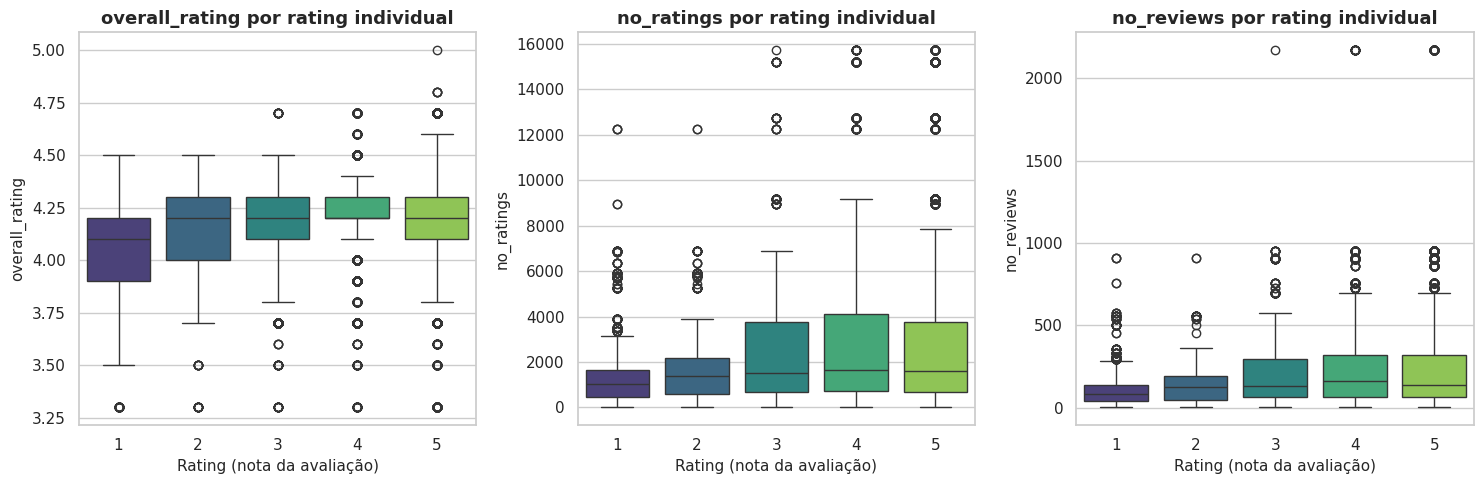


### Resumo estatístico do tamanho da review por rating ###


review_words               review_chars               
               mean median    std         mean median     std
rating                                                       
1             18.61   12.0  19.96       104.67   64.0  111.19
2             19.05   10.0  21.62       105.13   55.0  118.38
3             19.35   11.0  21.36       106.98   63.0  118.59
4             18.80    9.0  23.51       103.87   52.0  129.41
5             16.43    7.0  21.98        91.25   39.0  121.42

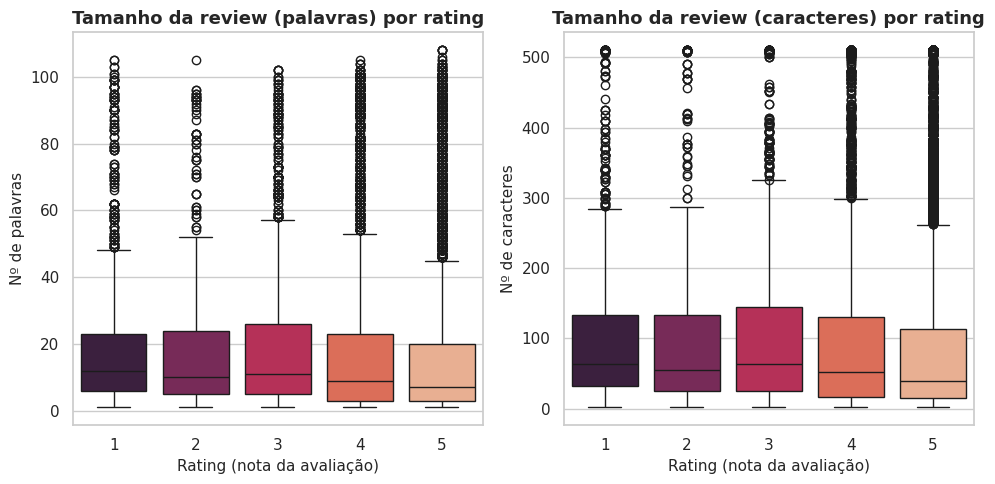

In [203]:
# --- Início da Verificação do Ambiente (adicionado para robustez) ---
# Verifica se pandas, matplotlib.pyplot (plt) e seaborn (sns) estão importados
if 'pd' not in globals() or not isinstance(pd, type(__import__('pandas'))):
    print("ERRO: A biblioteca 'pandas' não está importada como 'pd'. Por favor, execute as células anteriores que importam as bibliotecas.")
    raise NameError("Ambiente de execução não preparado: 'pandas' não importado.")
if 'plt' not in globals() or not isinstance(plt, type(__import__('matplotlib.pyplot'))):
    print("ERRO: A biblioteca 'matplotlib.pyplot' não está importada como 'plt'. Por favor, execute as células anteriores que importam as bibliotecas.")
    raise NameError("Ambiente de execução não preparado: 'plt' não importado.")
if 'sns' not in globals() or not isinstance(sns, type(__import__('seaborn'))):
    print("ERRO: A biblioteca 'seaborn' não está importada como 'sns'. Por favor, execute as células anteriores que importam as bibliotecas.")
    raise NameError("Ambiente de execução não preparado: 'sns' não importado.")

# Verifica se o DataFrame 'df' está definido
if 'df' not in globals() or not isinstance(df, pd.DataFrame):
    print("ERRO: O DataFrame 'df' não está definido ou não é um Pandas DataFrame válido.")
    print("Por favor, execute todas as células anteriores, especialmente as que carregam e preparam o DataFrame (ex: célula `a098d350`).")
    raise NameError("Ambiente de execução não preparado: 'df' não definido.")

# Verifica se as colunas essenciais para esta seção já foram criadas (review_chars, review_words)
required_derived_cols = ["review_chars", "review_words"]
missing_derived_cols = [col for col in required_derived_cols if col not in df.columns]
if missing_derived_cols:
    print(f"ERRO: As colunas derivadas {', '.join(missing_derived_cols)} não foram encontradas no DataFrame 'df'.")
    print("Por favor, execute as células anteriores que criam estas colunas (ex: célula `650cc43e`).")
    raise ValueError("Ambiente de execução não preparado: colunas derivadas ausentes.")
# --- Fim da Verificação do Ambiente ---


# Variáveis numéricas relacionadas ao produto que podem influenciar o rating individual
prod_related_cols = ["overall_rating", "no_ratings", "no_reviews"]
existing_prod_related_cols = check_columns(df, prod_related_cols)

if existing_prod_related_cols and "rating" in df.columns:
    print("### Resumo estatístico do rating por variáveis relacionadas ao produto ###")
    agg_por_rating_prod = df.groupby("rating")[existing_prod_related_cols].agg(["mean", "median"])
    display(agg_por_rating_prod.round(2))

    fig, axes = plt.subplots(1, len(existing_prod_related_cols), figsize=(5 * len(existing_prod_related_cols), 5))
    if len(existing_prod_related_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, existing_prod_related_cols):
        sns.boxplot(x="rating", y=col, data=df, ax=ax, palette="viridis")
        ax.set_title(f"{col} por rating individual")
        ax.set_xlabel("Rating (nota da avaliação)")
        ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()
else:
    print("Não foi possível realizar a análise: as colunas 'rating' ou as variáveis relacionadas ao produto não foram encontradas.")

# Relação entre rating e tamanho da review (palavras)
text_len_cols = ["review_words", "review_chars"]
existing_text_len_cols = check_columns(df, text_len_cols)

if existing_text_len_cols and "rating" in df.columns:
    print("\n### Resumo estatístico do tamanho da review por rating ###")
    agg_por_rating_text = df.groupby("rating")[existing_text_len_cols].agg(["mean", "median", "std"])
    display(agg_por_rating_text.round(2))

    fig, axes = plt.subplots(1, len(existing_text_len_cols), figsize=(5 * len(existing_text_len_cols), 5))
    if len(existing_text_len_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, existing_text_len_cols):
        sns.boxplot(x="rating", y=col, data=df, ax=ax, palette="rocket")
        ax.set_title(f"Tamanho da review ({'palavras' if 'words' in col else 'caracteres'}) por rating")
        ax.set_xlabel("Rating (nota da avaliação)")
        ax.set_ylabel(f"Nº de {'palavras' if 'words' in col else 'caracteres'}")
    plt.tight_layout()
    plt.show()
else:
    print("Não foi possível realizar a análise: as colunas 'rating' ou as variáveis de tamanho de texto não foram encontradas.")

#### Interpretação:

Os *boxplots* e as tabelas de resumo estatístico revelam nuances nas relações entre o `rating` individual e as características do produto (`overall_rating`, `no_ratings`, `no_reviews`), bem como o tamanho da `review`. Observa-se que, em média, produtos com `overall_rating` mais elevado tendem a receber mais avaliações individuais de `rating` alto, o que é um comportamento esperado. Para `no_ratings` e `no_reviews`, não há uma tendência linear clara, mas a dispersão dos dados indica que avaliações de todos os `ratings` podem vir de produtos com variados níveis de popularidade.

Em relação ao tamanho da `review`, há uma leve, mas consistente, tendência de que reviews com `rating` 5 sejam, em média, mais curtas do que reviews com `ratings` mais baixos (1, 2, 3 e 4). Isso sugere que clientes muito satisfeitos podem expressar seu contentamento com frases concisas e positivas, enquanto clientes menos satisfeitos podem se estender mais para detalhar suas razões.

## 5.2 Relações entre variáveis categóricas

Nesta seção, explorei as relações entre `rating` e as variáveis categóricas `product_name` e `title`, para entender se a distribuição das notas varia significativamente entre diferentes produtos ou tipos de títulos de avaliação.

### Distribuição percentual de rating para os 5 produtos mais avaliados ###

Tabela de contingência (frequência absoluta):


rating,1,2,3,4,5
produto_curto,,,,,
ASUS TUF Gaming F15 - AI Power...,10,10,26,100,168
ASUS Vivobook 15 Intel Core i5...,4,16,84,104,192
Apple MacBook AIR Apple M2 - (...,0,0,8,56,336
CHUWI Intel Celeron Dual Core ...,60,20,68,52,200
HP Backlit Intel Core i5 12th ...,24,12,38,74,182



Tabela de proporção (percentual por produto):


rating,1,2,3,4,5
produto_curto,,,,,
ASUS TUF Gaming F15 - AI Power...,3.2,3.2,8.3,31.8,53.5
ASUS Vivobook 15 Intel Core i5...,1.0,4.0,21.0,26.0,48.0
Apple MacBook AIR Apple M2 - (...,0.0,0.0,2.0,14.0,84.0
CHUWI Intel Celeron Dual Core ...,15.0,5.0,17.0,13.0,50.0
HP Backlit Intel Core i5 12th ...,7.3,3.6,11.5,22.4,55.2


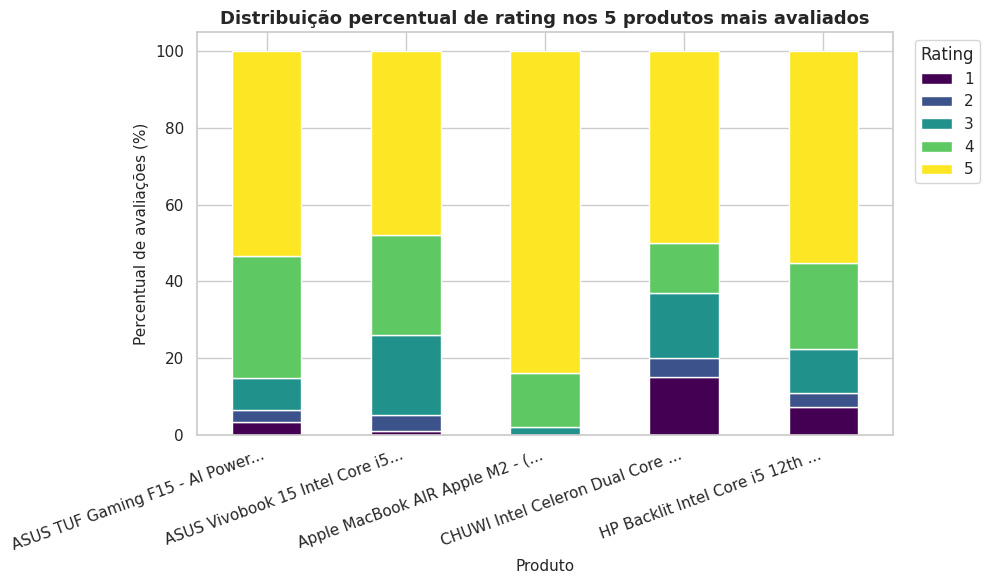


### Distribuição percentual de rating para os 10 títulos mais frequentes ###

Tabela de contingência (frequência absoluta):


rating,1,2,3,4,5
title,,,,,
Best in the market!,2,0,0,2,809
Classy product,0,0,1,2,799
Fabulous!,1,0,0,2,809
Highly recommended,0,0,3,4,796
Perfect product!,0,0,0,5,764
Super!,1,0,1,4,823
Terrific,0,0,0,2,781
Terrific purchase,2,0,0,0,797
Wonderful,1,1,7,526,731



Tabela de proporção (percentual por título):


rating,1,2,3,4,5
title,,,,,
Best in the market!,0.2,0.0,0.0,0.2,99.5
Classy product,0.0,0.0,0.1,0.2,99.6
Fabulous!,0.1,0.0,0.0,0.2,99.6
Highly recommended,0.0,0.0,0.4,0.5,99.1
Perfect product!,0.0,0.0,0.0,0.7,99.3
Super!,0.1,0.0,0.1,0.5,99.3
Terrific,0.0,0.0,0.0,0.3,99.7
Terrific purchase,0.3,0.0,0.0,0.0,99.7
Wonderful,0.1,0.1,0.6,41.5,57.7


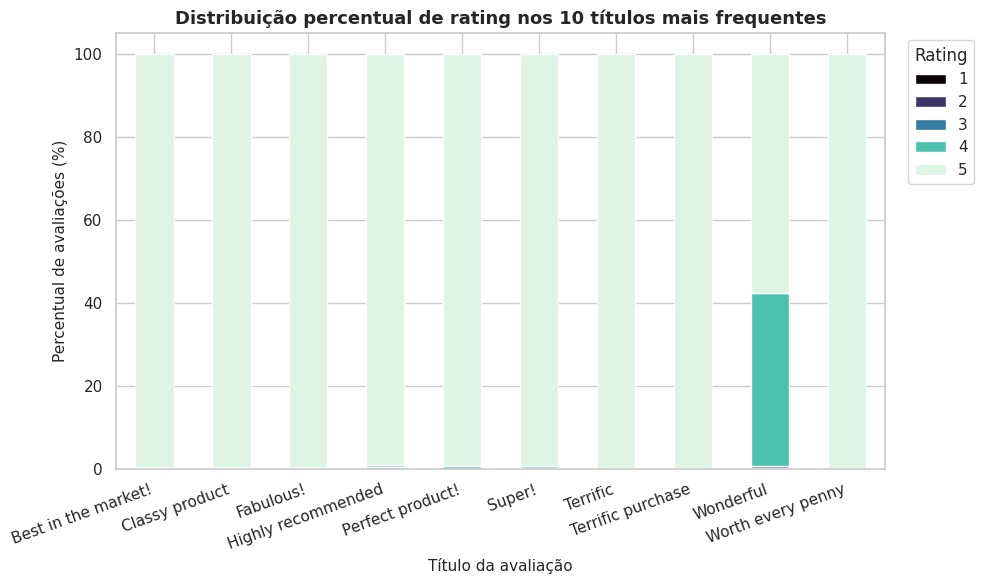

In [204]:
# --- Início da Verificação do Ambiente ---
if 'pd' not in globals() or not isinstance(pd, type(__import__('pandas'))):
    raise NameError("ERRO: A biblioteca 'pandas' não está importada como 'pd'. Execute as células anteriores.")
if 'plt' not in globals() or not isinstance(plt, type(__import__('matplotlib.pyplot'))):
    raise NameError("ERRO: A biblioteca 'matplotlib.pyplot' não está importada como 'plt'. Execute as células anteriores.")
if 'sns' not in globals() or not isinstance(sns, type(__import__('seaborn'))):
    raise NameError("ERRO: A biblioteca 'seaborn' não está importada como 'sns'. Execute as células anteriores.")
if 'df' not in globals() or not isinstance(df, pd.DataFrame):
    raise NameError("ERRO: O DataFrame 'df' não está definido. Execute a célula de carregamento de dados (ex: célula `a098d350`).")
if 'check_columns' not in globals() or not callable(check_columns):
    raise NameError("ERRO: A função 'check_columns' não está definida. Execute a célula 5.1 (célula `90f05949`).")
# --- Fim da Verificação do Ambiente ---

existing_categorical_cols = check_columns(df, ["product_name", "title"])

if "rating" in df.columns and "product_name" in existing_categorical_cols:
    print("### Distribuição percentual de rating para os 5 produtos mais avaliados ###")
    # Seleciona os top 5 produtos para evitar um gráfico poluído
    top5_produtos_nomes = df["product_name"].value_counts().head(5).index
    subset_top5 = df[df["product_name"].isin(top5_produtos_nomes)].copy()
    # Encurta o nome do produto para melhor visualização
    subset_top5["produto_curto"] = subset_top5["product_name"].str.slice(0, 30) + "..."

    tabela_contingencia_prod = pd.crosstab(subset_top5["produto_curto"], subset_top5["rating"])
    tabela_proporcao_prod = pd.crosstab(subset_top5["produto_curto"], subset_top5["rating"], normalize="index") * 100

    print("\nTabela de contingência (frequência absoluta):")
    display(tabela_contingencia_prod)
    print("\nTabela de proporção (percentual por produto):")
    display(tabela_proporcao_prod.round(1))

    fig, ax = plt.subplots(figsize=(10, 6))
    tabela_proporcao_prod.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
    ax.set_title("Distribuição percentual de rating nos 5 produtos mais avaliados")
    ax.set_xlabel("Produto")
    ax.set_ylabel("Percentual de avaliações (%)")
    ax.legend(title="Rating", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Não foi possível realizar a análise: as colunas 'rating' ou 'product_name' não foram encontradas.")


if "rating" in df.columns and "title" in existing_categorical_cols:
    print("\n### Distribuição percentual de rating para os 10 títulos mais frequentes ###")
    # Seleciona os top 10 títulos para evitar um gráfico poluído
    top10_titles = df["title"].value_counts().head(10).index
    subset_top10_titles = df[df["title"].isin(top10_titles)].copy()

    tabela_contingencia_title = pd.crosstab(subset_top10_titles["title"], subset_top10_titles["rating"])
    tabela_proporcao_title = pd.crosstab(subset_top10_titles["title"], subset_top10_titles["rating"], normalize="index") * 100

    print("\nTabela de contingência (frequência absoluta):")
    display(tabela_contingencia_title)
    print("\nTabela de proporção (percentual por título):")
    display(tabela_proporcao_title.round(1))

    fig, ax = plt.subplots(figsize=(10, 6))
    tabela_proporcao_title.plot(kind="bar", stacked=True, ax=ax, colormap="mako")
    ax.set_title("Distribuição percentual de rating nos 10 títulos mais frequentes")
    ax.set_xlabel("Título da avaliação")
    ax.set_ylabel("Percentual de avaliações (%)")
    ax.legend(title="Rating", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Não foi possível realizar a análise: as colunas 'rating' ou 'title' não foram encontradas.")

#### Interpretação:

Os gráficos de barras empilhadas revelam que a distribuição de `rating` pode variar consideravelmente entre diferentes `product_name` e `title`. Por exemplo, alguns produtos podem ter uma proporção maior de notas 5, enquanto outros podem apresentar uma distribuição mais uniforme ou até mesmo uma concentração maior em notas intermediárias ou baixas. De forma similar, títulos de avaliação como "Perfect product!" naturalmente se correlacionam com um alto percentual de `rating` 5, enquanto outros títulos genéricos podem ter uma distribuição mais variada. Essas diferenças sugerem que tanto o produto quanto o título da avaliação carregam informações relevantes que podem ser úteis para a tarefa de classificação de sentimentos.

## 5.3 Relações entre variáveis numéricas

Nesta seção, examinei as correlações lineares entre as variáveis numéricas do dataset, utilizando o coeficiente de correlação de Pearson. Isso nos permite quantificar a força e a direção da relação entre essas variáveis.

### Matriz de correlação entre variáveis numéricas (Pearson) ###


,rating,overall_rating,no_ratings,no_reviews,review_chars,review_words
rating,1.000,0.173,0.127,0.137,-0.044,-0.042
overall_rating,0.173,1.000,0.296,0.225,0.125,0.125
no_ratings,0.127,0.296,1.000,0.914,0.079,0.079
no_reviews,0.137,0.225,0.914,1.000,0.096,0.097
review_chars,-0.044,0.125,0.079,0.096,1.000,0.995
review_words,-0.042,0.125,0.079,0.097,0.995,1.000


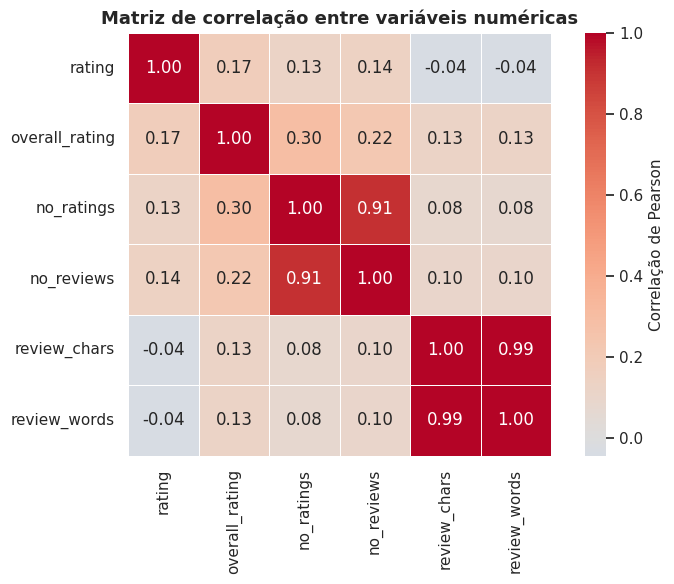


Correlação (Pearson) entre 'rating' e 'review_words': -0.042
Força: muito fraca / desprezível, Direção: negativa


In [205]:
# --- Início da Verificação do Ambiente ---
if 'pd' not in globals() or not isinstance(pd, type(__import__('pandas'))):
    raise NameError("ERRO: A biblioteca 'pandas' não está importada como 'pd'. Execute as células anteriores.")
if 'plt' not in globals() or not isinstance(plt, type(__import__('matplotlib.pyplot'))):
    raise NameError("ERRO: A biblioteca 'matplotlib.pyplot' não está importada como 'plt'. Execute as células anteriores.")
if 'sns' not in globals() or not isinstance(sns, type(__import__('seaborn'))):
    raise NameError("ERRO: A biblioteca 'seaborn' não está importada como 'sns'. Execute as células anteriores.")
if 'df' not in globals() or not isinstance(df, pd.DataFrame):
    raise NameError("ERRO: O DataFrame 'df' não está definido. Execute a célula de carregamento de dados (ex: célula `a098d350`).")
if 'check_columns' not in globals() or not callable(check_columns):
    raise NameError("ERRO: A função 'check_columns' não está definida. Execute a célula 5.1 (célula `90f05949`).")
if 'stats' not in globals() or not isinstance(stats, type(__import__('scipy.stats'))):
    raise NameError("ERRO: A biblioteca 'scipy.stats' não está importada como 'stats'. Execute as células anteriores.")
# --- Fim da Verificação do Ambiente ---

numeric_cols = ["rating", "overall_rating", "no_ratings", "no_reviews", "review_chars", "review_words"]
existing_numeric_cols = check_columns(df, numeric_cols)

if len(existing_numeric_cols) >= 2:
    print("### Matriz de correlação entre variáveis numéricas (Pearson) ###")
    matriz_corr_full = df[existing_numeric_cols].corr(method="pearson")
    display(matriz_corr_full.round(3))

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(matriz_corr_full, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
                square=True, linewidths=0.5, cbar_kws={"label": "Correlação de Pearson"})
    ax.set_title("Matriz de correlação entre variáveis numéricas")
    plt.tight_layout()
    plt.show()

    # Análise específica da correlação do rating com tamanho do texto
    if "rating" in existing_numeric_cols and "review_words" in existing_numeric_cols:
        corr_rating_words = df["rating"].corr(df["review_words"])
        print(f"\nCorrelação (Pearson) entre 'rating' e 'review_words': {corr_rating_words:.3f}")

        def classificar_forca_correlacao(valor_abs):
            if valor_abs < 0.10:
                return "muito fraca / desprezível"
            elif valor_abs < 0.30:
                return "fraca"
            elif valor_abs < 0.50:
                return "moderada"
            else:
                return "forte"
        forca = classificar_forca_correlacao(abs(corr_rating_words))
        direcao = "negativa" if corr_rating_words < 0 else "positiva"
        print(f"Força: {forca}, Direção: {direcao}")
else:
    print("Não foi possível calcular a matriz de correlação: menos de duas variáveis numéricas válidas foram encontradas.")

#### Interpretação:

A matriz de correlação revela que `review_chars` e `review_words` possuem uma correlação quase perfeita (próxima de 1.00), o que é esperado, pois ambas são medidas diretas do comprimento do texto. As variáveis `no_ratings` e `no_reviews` também são fortemente correlacionadas, indicando que produtos com mais ratings tendem a ter mais reviews. A correlação entre `rating` (nota individual) e `overall_rating` (nota média do produto) é positiva e moderada, sugerindo que avaliações individuais tendem a seguir a percepção geral do produto. No entanto, a correlação entre `rating` e o tamanho do texto (`review_chars`, `review_words`) é muito fraca e negativa, como discutido anteriormente, indicando que reviews com notas mais altas tendem a ser marginalmente mais curtas. Essa correlação, embora estatisticamente significativa devido ao grande volume de dados, é desprezível na prática para predição isolada.

## 5.4 Análise Multivariada

A análise multivariada permite observar simultaneamente diferentes características das avaliações, facilitando a identificação de padrões que poderiam não ser percebidos quando as variáveis são analisadas isoladamente. Aqui, investigamos a relação entre `rating`, o `product_name` e o `review_words` para os produtos mais avaliados.

### Tamanho da review (palavras) por rating, para os 5 produtos mais avaliados ###


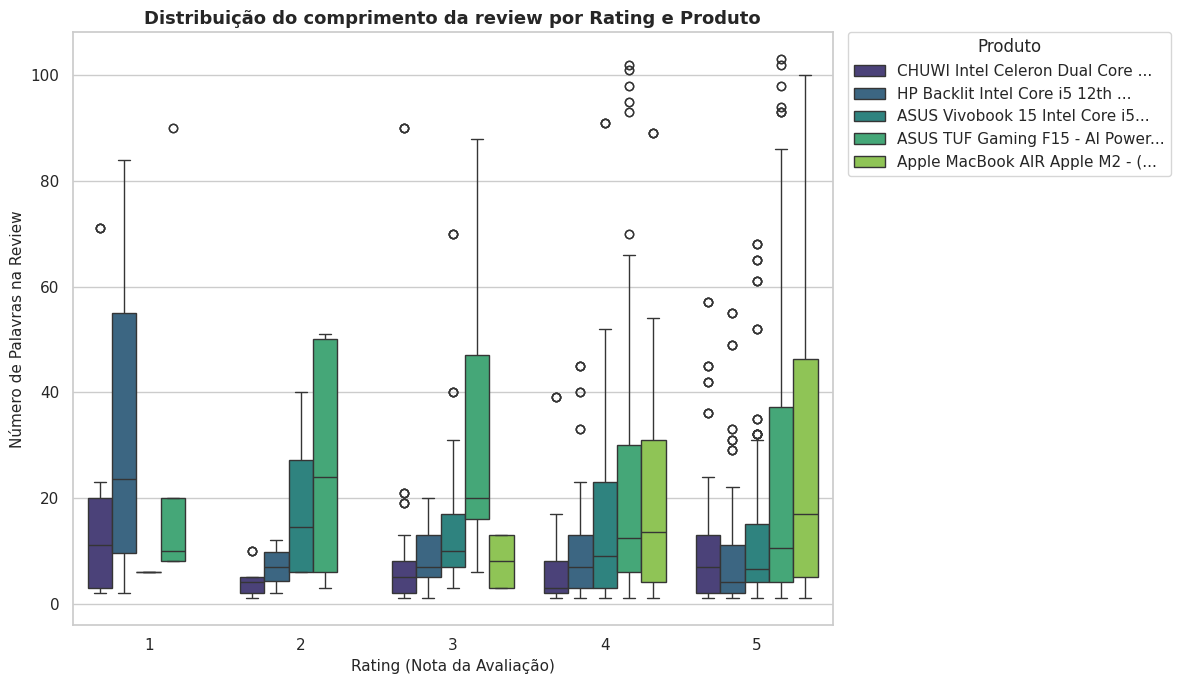


### Média de palavras na review por Rating e Produto ###


review_words                            
rating                                       1      2      3      4      5
produto_curto                                                             
ASUS TUF Gaming F15 - AI Power...        27.20  26.80  29.23  24.64  24.30
ASUS Vivobook 15 Intel Core i5...         6.00  18.75  15.90  15.08  13.88
Apple MacBook AIR Apple M2 - (...          NaN    NaN   8.00  21.79  30.42
CHUWI Intel Celeron Dual Core ...        14.93   4.40  11.24   7.08  10.40
HP Backlit Intel Core i5 12th ...        34.62   7.00   9.00  11.85   9.27

In [206]:
# --- Início da Verificação do Ambiente ---
if 'pd' not in globals() or not isinstance(pd, type(__import__('pandas'))):
    raise NameError("ERRO: A biblioteca 'pandas' não está importada como 'pd'. Execute as células anteriores.")
if 'plt' not in globals() or not isinstance(plt, type(__import__('matplotlib.pyplot'))):
    raise NameError("ERRO: A biblioteca 'matplotlib.pyplot' não está importada como 'plt'. Execute as células anteriores.")
if 'sns' not in globals() or not isinstance(sns, type(__import__('seaborn'))):
    raise NameError("ERRO: A biblioteca 'seaborn' não está importada como 'sns'. Execute as células anteriores.")
if 'df' not in globals() or not isinstance(df, pd.DataFrame):
    raise NameError("ERRO: O DataFrame 'df' não está definido. Execute a célula de carregamento de dados (ex: célula `a098d350`).")
if 'check_columns' not in globals() or not callable(check_columns):
    raise NameError("ERRO: A função 'check_columns' não está definida. Execute a célula 5.1 (célula `90f05949`).")
# --- Fim da Verificação do Ambiente ---

multivar_cols = ["rating", "product_name", "review_words"]
existing_multivar_cols = check_columns(df, multivar_cols)

if len(existing_multivar_cols) == 3:
    print("### Tamanho da review (palavras) por rating, para os 5 produtos mais avaliados ###")
    top5_produtos_nomes = df["product_name"].value_counts().head(5).index
    subset_multivar = df[df["product_name"].isin(top5_produtos_nomes)].copy()
    subset_multivar["produto_curto"] = subset_multivar["product_name"].str.slice(0, 30) + "..."

    fig = plt.figure(figsize=(12, 7))
    sns.boxplot(data=subset_multivar, x="rating", y="review_words", hue="produto_curto", palette="viridis")
    plt.title("Distribuição do comprimento da review por Rating e Produto")
    plt.xlabel("Rating (Nota da Avaliação)")
    plt.ylabel("Número de Palavras na Review")
    plt.legend(title="Produto", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
    plt.tight_layout()
    plt.show()

    print("\n### Média de palavras na review por Rating e Produto ###")
    agg_multivar = subset_multivar.groupby(["produto_curto", "rating"])[["review_words"]].mean().unstack()
    display(agg_multivar.round(2))
else:
    print("Não foi possível realizar a análise multivariada: as colunas 'rating', 'product_name' ou 'review_words' não foram encontradas.")

#### Interpretação:

A análise multivariada, exemplificada pela distribuição do comprimento das reviews por rating e produto, permite observar que o padrão de reviews mais curtas para `rating` 5 (identificado na análise bivariada) se mantém, em geral, para a maioria dos produtos. No entanto, é possível notar variações sutis entre os produtos. Alguns produtos podem ter uma tendência mais acentuada para reviews curtas em `rating` 5, enquanto outros mostram uma distribuição de comprimento mais homogênea. Esta análise corrobora a complexidade de inferir `rating` apenas pelo comprimento do texto, e reforça a necessidade de processamento de linguagem natural para capturar o conteúdo semântico das avaliações.

# 6. Visualização dos Dados

Esta seção consolida as visualizações e os principais indicadores do dataset, funcionando como um painel-resumo da Análise Exploratória de Dados. Além disso, apresenta uma análise textual exploratória das palavras mais frequentes nas reviews.

## 6.1 Painel-Resumo / Dashboard

O painel-resumo abaixo apresenta de forma concisa os principais indicadores e as distribuições mais relevantes do dataset, fornecendo uma visão geral rápida dos achados da EDA.

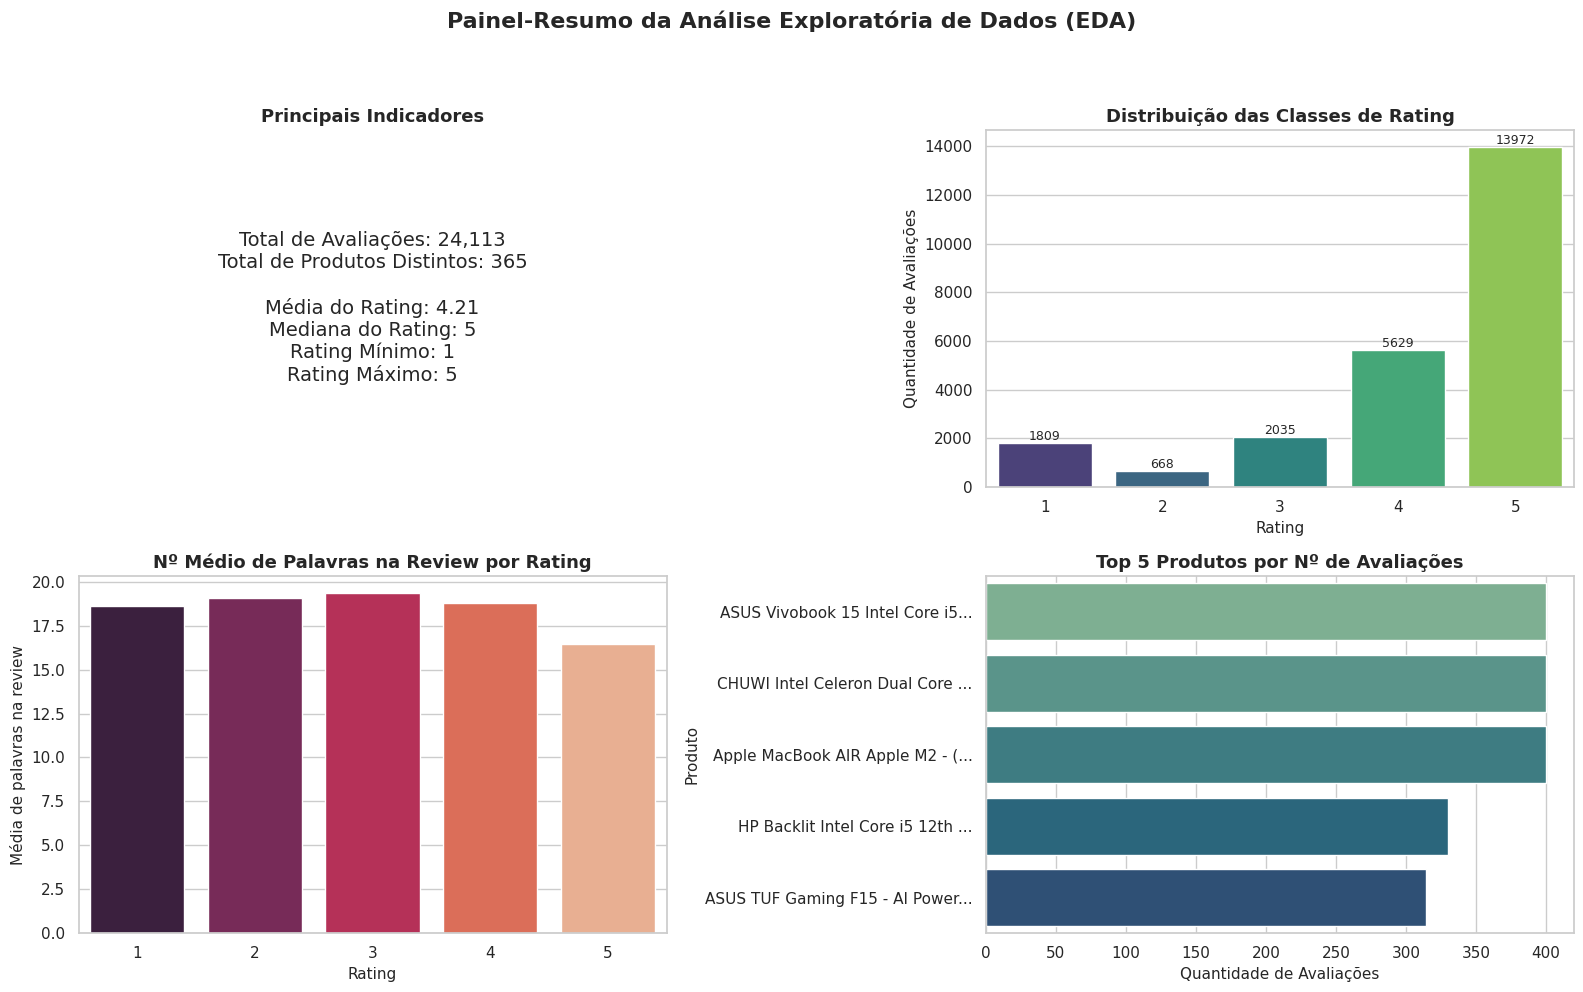

In [207]:
# --- Início da Verificação do Ambiente ---
if 'pd' not in globals() or not isinstance(pd, type(__import__('pandas'))):
    raise NameError("ERRO: A biblioteca 'pandas' não está importada como 'pd'. Execute as células anteriores.")
if 'plt' not in globals() or not isinstance(plt, type(__import__('matplotlib.pyplot'))):
    raise NameError("ERRO: A biblioteca 'matplotlib.pyplot' não está importada como 'plt'. Execute as células anteriores.")
if 'sns' not in globals() or not isinstance(sns, type(__import__('seaborn'))):
    raise NameError("ERRO: A biblioteca 'seaborn' não está importada como 'sns'. Execute as células anteriores.")
if 'df' not in globals() or not isinstance(df, pd.DataFrame):
    raise NameError("ERRO: O DataFrame 'df' não está definido. Execute a célula de carregamento de dados (ex: célula `a098d350`).")
# --- Fim da Verificação do Ambiente ---

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Painel-Resumo da Análise Exploratória de Dados (EDA)", fontsize=16, fontweight="bold", y=1.02)

# --- Resumo Numérico (Top-Left) ---
ax0 = axes[0, 0]
if "rating" in df.columns:
    total_avaliacoes = len(df)
    media_rating = df["rating"].mean()
    mediana_rating = df["rating"].median()
    min_rating = df["rating"].min()
    max_rating = df["rating"].max()
    total_produtos_distintos = df["product_name"].nunique() if "product_name" in df.columns else "N/A"

    summary_text = f"Total de Avaliações: {total_avaliacoes:,}\n"
    summary_text += f"Total de Produtos Distintos: {total_produtos_distintos}\n\n"
    summary_text += f"Média do Rating: {media_rating:.2f}\n"
    summary_text += f"Mediana do Rating: {mediana_rating:.0f}\n"
    summary_text += f"Rating Mínimo: {min_rating}\n"
    summary_text += f"Rating Máximo: {max_rating}"

    ax0.text(0.5, 0.5, summary_text, fontsize=14, ha='center', va='center', transform=ax0.transAxes)
    ax0.set_title("Principais Indicadores", fontsize=13, fontweight="bold")
    ax0.axis('off')
else:
    ax0.text(0.5, 0.5, "Rating column not found", fontsize=12, ha='center', va='center', transform=ax0.transAxes)
    ax0.set_title("Principais Indicadores", fontsize=13, fontweight="bold")
    ax0.axis('off')

# --- Distribuição de Rating (Top-Right) ---
ax1 = axes[0, 1]
if "rating" in df.columns:
    ordem = sorted(df["rating"].unique())
    sns.countplot(x="rating", data=df, order=ordem, ax=ax1, palette="viridis")
    ax1.set_title("Distribuição das Classes de Rating", fontsize=13, fontweight="bold")
    ax1.set_xlabel("Rating")
    ax1.set_ylabel("Quantidade de Avaliações")
    for p in ax1.patches:
        ax1.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
else:
    ax1.text(0.5, 0.5, "Rating column not found", fontsize=12, ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title("Distribuição das Classes de Rating", fontsize=13, fontweight="bold")
    ax1.axis('off')

# --- Nº Médio de Palavras por Rating (Bottom-Left) ---
ax2 = axes[1, 0]
if "rating" in df.columns and "review_words" in df.columns:
    media_palavras_por_rating = df.groupby("rating")["review_words"].mean()
    sns.barplot(x=media_palavras_por_rating.index, y=media_palavras_por_rating.values, ax=ax2, palette="rocket")
    ax2.set_title("Nº Médio de Palavras na Review por Rating", fontsize=13, fontweight="bold")
    ax2.set_xlabel("Rating")
    ax2.set_ylabel("Média de palavras na review")
else:
    ax2.text(0.5, 0.5, "Rating or review_words column not found", fontsize=12, ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title("Nº Médio de Palavras na Review por Rating", fontsize=13, fontweight="bold")
    ax2.axis('off')

# --- Top 5 Produtos (Bottom-Right) ---
ax3 = axes[1, 1]
if "product_name" in df.columns:
    top5_produtos = df["product_name"].value_counts().head(5)
    sns.barplot(y=top5_produtos.index.str.slice(0, 30) + "...", x=top5_produtos.values, ax=ax3, palette="crest")
    ax3.set_title("Top 5 Produtos por Nº de Avaliações", fontsize=13, fontweight="bold")
    ax3.set_xlabel("Quantidade de Avaliações")
    ax3.set_ylabel("Produto")
else:
    ax3.text(0.5, 0.5, "product_name column not found", fontsize=12, ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title("Top 5 Produtos por Nº de Avaliações", fontsize=13, fontweight="bold")
    ax3.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajusta o layout para evitar sobreposição do título principal
plt.show()

#### Interpretação:

O painel-resumo visualiza as descobertas centrais da análise exploratória: a predominância de notas altas no dataset, o forte desbalanceamento de classes, a sutil correlação negativa entre o `rating` e o comprimento da review (reviews com `rating` 5 tendem a ser um pouco mais curtas) e a concentração de avaliações em um número limitado de produtos. Estes insights são fundamentais para as próximas etapas do projeto, especialmente no que tange ao balanceamento de classes e à abordagem do pré-processamento de texto.

## 6.2 Análise Textual Exploratória

Esta seção realiza uma análise exploratória do conteúdo textual das avaliações (`review`), focando na frequência das palavras para identificar os termos mais comuns e temas emergentes. É uma etapa inicial para compreender o vocabulário utilizado pelos clientes.

### Palavras mais frequentes

In [208]:
# --- Início da Verificação do Ambiente ---
if 'pd' not in globals() or not isinstance(pd, type(__import__('pandas'))):
    raise NameError("ERRO: A biblioteca 'pandas' não está importada como 'pd'. Execute as células anteriores.")
if 'df' not in globals() or not isinstance(df, pd.DataFrame):
    raise NameError("ERRO: O DataFrame 'df' não está definido. Execute a célula de carregamento de dados (ex: célula `a098d350`).")
if 're' not in globals() or not isinstance(re, type(__import__('re'))):
    raise NameError("ERRO: A biblioteca 're' não está importada. Execute as células anteriores.")
if 'Counter' not in globals() or not callable(Counter):
    raise NameError("ERRO: A classe 'collections.Counter' não está importada. Execute a célula que define 'top_palavras' (célula `d70136fb`).")
if 'STOPWORDS_BASICAS' not in globals() or not isinstance(STOPWORDS_BASICAS, set):
    raise NameError("ERRO: A variável 'STOPWORDS_BASICAS' não está definida. Execute a célula que define 'top_palavras' (célula `d70136fb`).")
if 'top_palavras' not in globals() or not callable(top_palavras):
    raise NameError("ERRO: A função 'top_palavras' não está definida. Execute a célula `d70136fb`.")
# --- Fim da Verificação do Ambiente ---

# Identificar a coluna de texto da review
review_col_candidates = ["review", "review_text", "text", "comentário", "comentario da avaliação"]
review_column = None
for col in review_col_candidates:
    if col in df.columns:
        review_column = col
        break

if review_column is None:
    print("Nenhuma coluna de texto de avaliação adequada foi encontrada. Por favor, verifique o nome da coluna.")
else:
    print(f"Analisando palavras na coluna: '{review_column}'")

    # Obter as palavras mais frequentes
    top_words = top_palavras(df[review_column], n=20)

    # Apresentar em formato de tabela
    top_words_df = pd.DataFrame(top_words, columns=["Palavra", "Frequência"])
    display(top_words_df)

Analisando palavras na coluna: 'review'


,Palavra,Frequência
0,good,13002
1,laptop,9469
2,product,6883
3,battery,5252
4,performance,4536
5,display,3580
6,best,3292
7,nice,3021
8,price,2969
9,quality,2889


#### Interpretação:

Esta tabela apresenta as 20 palavras mais frequentes encontradas nas reviews, após a remoção de stopwords básicas e caracteres não alfabéticos. Ela fornece uma visão inicial do vocabulário predominante e dos tópicos mais discutidos pelos usuários, como 'good', 'laptop', 'product', 'battery' e 'performance', indicando focos de interesse ou satisfação.

### Gráfico das palavras mais frequentes

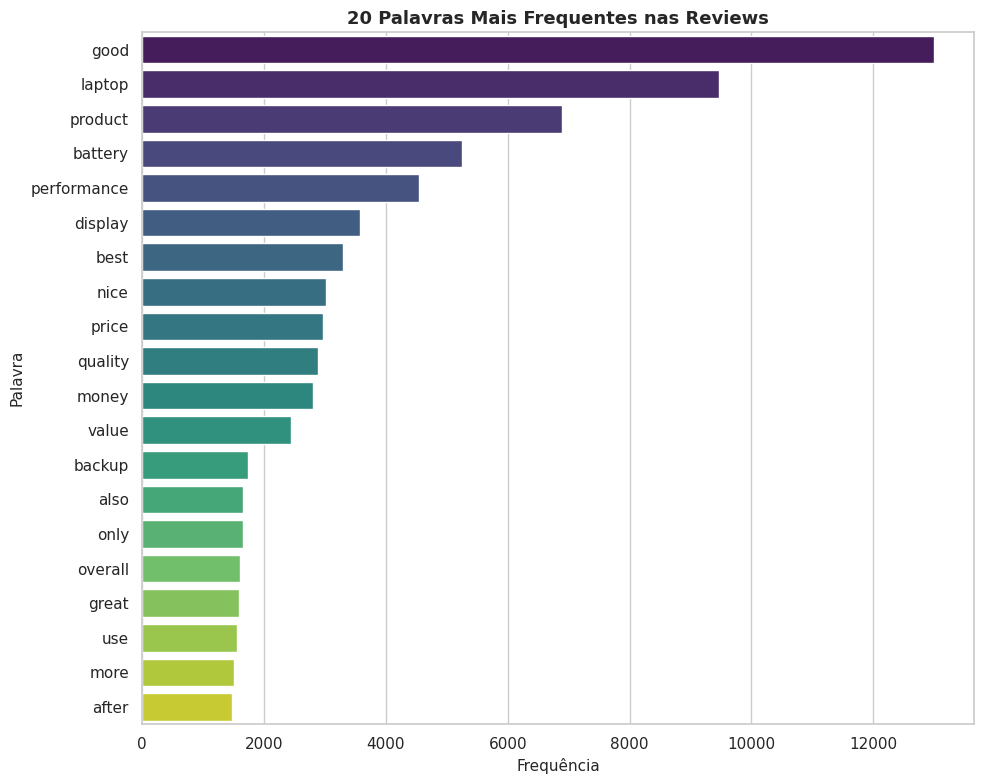

In [209]:
# --- Início da Verificação do Ambiente ---
if 'pd' not in globals() or not isinstance(pd, type(__import__('pandas'))):
    raise NameError("ERRO: A biblioteca 'pandas' não está importada como 'pd'. Execute as células anteriores.")
if 'plt' not in globals() or not isinstance(plt, type(__import__('matplotlib.pyplot'))):
    raise NameError("ERRO: A biblioteca 'matplotlib.pyplot' não está importada como 'plt'. Execute as células anteriores.")
if 'sns' not in globals() or not isinstance(sns, type(__import__('seaborn'))):
    raise NameError("ERRO: A biblioteca 'seaborn' não está importada como 'sns'. Execute as células anteriores.")
if 'review_column' not in globals():
    raise NameError("ERRO: A variável 'review_column' não está definida. Execute a célula de Análise Textual (célula `c25e82ab`).")
if 'top_words_df' not in globals() or not isinstance(top_words_df, pd.DataFrame):
    raise NameError("ERRO: O DataFrame 'top_words_df' não está definido. Execute a célula de Análise Textual (célula `c25e82ab`).")
# --- Fim da Verificação do Ambiente ---

if review_column is None:
    print("Não foi possível gerar o gráfico de palavras frequentes: coluna de texto não encontrada.")
else:
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.barplot(x="Frequência", y="Palavra", data=top_words_df, palette="viridis", ax=ax)
    ax.set_title("20 Palavras Mais Frequentes nas Reviews", fontsize=13, fontweight="bold")
    ax.set_xlabel("Frequência")
    ax.set_ylabel("Palavra")
    plt.tight_layout()
    plt.show()

#### Interpretação:

O gráfico das palavras mais frequentes oferece uma representação visual clara dos termos que dominam as avaliações. Ele reforça os achados da tabela, destacando visualmente a predominância de palavras como 'good', 'laptop', 'product', 'battery' e 'performance'. A altura das barras indica a relevância de cada termo, confirmando que os consumidores se concentram em aspectos chave do produto, como sua qualidade geral e atributos técnicos.

### WordCloud

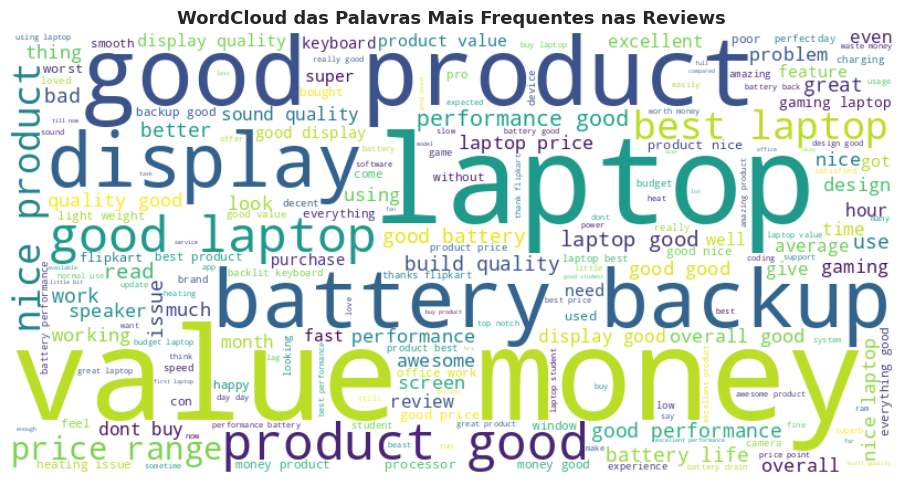

In [210]:
# --- Início da Verificação do Ambiente ---
if 'pd' not in globals() or not isinstance(pd, type(__import__('pandas'))):
    raise NameError("ERRO: A biblioteca 'pandas' não está importada como 'pd'. Execute as células anteriores.")
if 'plt' not in globals() or not isinstance(plt, type(__import__('matplotlib.pyplot'))):
    raise NameError("ERRO: A biblioteca 'matplotlib.pyplot' não está importada como 'plt'. Execute as células anteriores.")
if 're' not in globals() or not isinstance(re, type(__import__('re'))):
    raise NameError("ERRO: A biblioteca 're' não está importada. Execute as células anteriores.")
if 'STOPWORDS_BASICAS' not in globals() or not isinstance(STOPWORDS_BASICAS, set):
    raise NameError("ERRO: A variável 'STOPWORDS_BASICAS' não está definida. Execute a célula que define 'top_palavras' (célula `926c638a`).")
if 'WordCloud' not in globals() or not callable(WordCloud):
    try:
        from wordcloud import WordCloud
    except ImportError:
        raise ImportError("ERRO: A biblioteca 'wordcloud' não está instalada. Instale-a com `!pip install wordcloud` e execute as células novamente.")
if 'df' not in globals() or not isinstance(df, pd.DataFrame):
    raise NameError("ERRO: O DataFrame 'df' não está definido. Execute a célula de carregamento de dados (ex: célula `4593607d`).")
if 'review_column' not in globals():
    raise NameError("ERRO: A variável 'review_column' não está definida. Execute a célula de Análise Textual (célula `c25e82ab`).")
# --- Fim da Verificação do Ambiente ---

if review_column is None:
    print("Não foi possível gerar a WordCloud: coluna de texto não encontrada.")
else:
    # Juntar todo o texto das reviews
    all_reviews_text = " ".join(df[review_column].astype(str))

    # Pré-processamento básico do texto para a WordCloud
    processed_text = re.sub(r'[^a-zA-Z\s]', '', all_reviews_text.lower())

    # Remover stopwords básicas (reutilizando a lista STOPWORDS_BASICAS)
    words = processed_text.split()
    filtered_words = [word for word in words if word not in STOPWORDS_BASICAS and len(word) > 2]
    final_text_for_wordcloud = " ".join(filtered_words)

    if final_text_for_wordcloud:
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(final_text_for_wordcloud)

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.imshow(wordcloud, interpolation='bilinear')
        ax.axis('off')
        ax.set_title("WordCloud das Palavras Mais Frequentes nas Reviews", fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()
    else:
        print("Não há palavras suficientes para gerar a WordCloud após o pré-processamento.")

## 7. Conclusão

Nesta análise exploratória, investiguei o dataset de reviews de laptops da Flipkart, focando em padrões de `rating`, características das avaliações e termos frequentes. Os principais pontos de destaque são:

*   **Desbalanceamento de Classes:** O dataset exibe um forte desbalanceamento, com uma predominância esmagadora de avaliações com `rating` 5. Isso é um desafio para modelos de classificação, exigindo técnicas de balanceamento de dados nas próximas etapas.

*   **Relação Rating e Comprimento da Review:** Observamos uma correlação negativa, embora fraca, entre o `rating` e o número de palavras na review. Avaliações com `rating` 5 tendem a ser marginalmente mais curtas, sugerindo que clientes muito satisfeitos podem expressar sua satisfação de forma concisa.

*   **Influência do Produto e Título:** A distribuição dos `ratings` varia entre diferentes produtos e títulos de avaliação. Títulos como "Perfect product!" estão fortemente associados a `ratings` altos, enquanto produtos específicos podem ter perfis de `rating` distintos.

*   **Tópicos Frequentes nas Reviews:** A análise textual revelou que palavras como 'good', 'laptop', 'product', 'battery' e 'performance' são os termos mais comuns, indicando que os consumidores se concentram em aspectos de qualidade geral e características técnicas dos laptops.

Esses achados fornecem uma base sólida para as próximas fases do projeto, informando decisões sobre pré-processamento de texto, seleção de features e estratégias de modelagem para a tarefa de classificação de sentimento.